# Лабораторная 5: полный трансформер `encoder-decoder` на `WikiText-2 (GitHub train/valid/test)` (solution)

Полная реализация финальной лабораторной.


## Маршрут выполнения

1. Контракт данных.
2. Причинная маска.
3. Архитектура `encoder-decoder`.
4. Обучение и перплексия.
5. Детерминированная генерация.
6. Диагностика внимания.


In [1]:
import ctypes
import json
import os
import random
import subprocess
import sys
import time
from pathlib import Path

PROFILES = {
    'CPU-friendly': {
        'max_chars_train': 220_000,
        'max_chars_valid': 90_000,
        'max_chars_test': 90_000,
        'src_len': 72,
        'tgt_len': 72,
        'stride': 3,
        'batch_size': 64,
        'd_model': 128,
        'num_heads': 4,
        'd_ff': 256,
        'num_layers': 2,
        'dropout': 0.1,
        'learning_rate': 3e-4,
        'epochs': 14,
        'early_stopping_patience': 3,
        'probe_count': 20,
        'gen_len': 40,
        'per_probe_success_threshold': 0.60,
        'gen_success_threshold': 16,
        'gen_mean_threshold': 0.60,
        'generation_top_k': 5,
        'probe_split': 'valid',
    },
    'GPU-friendly': {
        'max_chars_train': 600_000,
        'max_chars_valid': 180_000,
        'max_chars_test': 180_000,
        'src_len': 80,
        'tgt_len': 80,
        'stride': 2,
        'batch_size': 128,
        'd_model': 192,
        'num_heads': 6,
        'd_ff': 512,
        'num_layers': 3,
        'dropout': 0.1,
        'learning_rate': 2.5e-4,
        'epochs': 18,
        'early_stopping_patience': 3,
        'probe_count': 20,
        'gen_len': 40,
        'per_probe_success_threshold': 0.60,
        'gen_success_threshold': 16,
        'gen_mean_threshold': 0.60,
        'generation_top_k': 20,
        'probe_split': 'valid',
    },
}

RUNTIME_PROFILE = os.getenv('COURSE_RUNTIME_PROFILE', 'CPU-friendly')
if RUNTIME_PROFILE not in PROFILES:
    raise ValueError(f'Неизвестный профиль: {RUNTIME_PROFILE}')

SEED = 42
RUN_STARTED_AT = time.time()
WIKITEXT2_GITHUB_URLS = {
    'train': 'https://raw.githubusercontent.com/pytorch/examples/main/word_language_model/data/wikitext-2/train.txt',
    'valid': 'https://raw.githubusercontent.com/pytorch/examples/main/word_language_model/data/wikitext-2/valid.txt',
    'test': 'https://raw.githubusercontent.com/pytorch/examples/main/word_language_model/data/wikitext-2/test.txt',
}
PAD_TOKEN = '<pad>'
SOS_TOKEN = '<sos>'


def _prepend_path_env(var_name: str, new_paths: list[Path]) -> None:
    """Добавляет пути в начало переменной окружения.

    Аргументы:
        var_name: Имя переменной окружения с путями.
        new_paths: Пути-кандидаты для добавления.

    Возвращает:
        None.

    Исключения:
        RuntimeError: Не выбрасывается в штатном режиме.
    """
    existing = os.environ.get(var_name, '')
    existing_parts = [part for part in existing.split(':') if part]
    merged: list[str] = []
    for path in new_paths:
        if path.is_dir():
            path_str = str(path)
            if path_str not in merged:
                merged.append(path_str)
    for part in existing_parts:
        if part not in merged:
            merged.append(part)
    if merged:
        os.environ[var_name] = ':'.join(merged)


def _detect_site_packages_dir() -> Path | None:
    """Возвращает каталог `site-packages` активной виртуальной среды.

    Аргументы:
        Нет.

    Возвращает:
        Путь к `site-packages` или `None`.

    Исключения:
        RuntimeError: Не выбрасывается в штатном режиме.
    """
    major, minor = sys.version_info[:2]
    candidate = Path(sys.prefix) / 'lib' / f'python{major}.{minor}' / 'site-packages'
    if candidate.is_dir():
        return candidate
    return None


def _preload_cuda_runtime_libraries(site_packages: Path) -> dict:
    """Предзагружает CUDA-библиотеки до импорта TensorFlow.

    Аргументы:
        site_packages: Каталог `site-packages` текущей среды.

    Возвращает:
        Словарь с ключами `loaded`, `missing`, `failed`.

    Исключения:
        RuntimeError: Не выбрасывается в штатном режиме.
    """
    nvidia_root = site_packages / 'nvidia'
    library_specs = [
        ('cuda_runtime', 'libcudart.so.12'),
        ('cublas', 'libcublas.so.12'),
        ('cublas', 'libcublasLt.so.12'),
        ('cudnn', 'libcudnn.so.9'),
        ('cufft', 'libcufft.so.11'),
        ('curand', 'libcurand.so.10'),
        ('cusolver', 'libcusolver.so.11'),
        ('cusparse', 'libcusparse.so.12'),
        ('nccl', 'libnccl.so.2'),
        ('nvjitlink', 'libnvJitLink.so.12'),
    ]

    loaded: list[str] = []
    missing: list[str] = []
    failed: list[str] = []

    for subdir, library_name in library_specs:
        library_path = nvidia_root / subdir / 'lib' / library_name
        if not library_path.is_file():
            missing.append(str(library_path))
            continue
        try:
            ctypes.CDLL(str(library_path), mode=ctypes.RTLD_GLOBAL)
            loaded.append(str(library_path))
        except OSError as exc:
            failed.append(f'{library_path}: {exc}')

    return {'loaded': loaded, 'missing': missing, 'failed': failed}


def _configure_local_gpu_runtime_env(runtime_profile: str) -> dict:
    """Готовит переменные окружения для локального запуска на GPU.

    Аргументы:
        runtime_profile: Текущий профиль (`CPU-friendly` или `GPU-friendly`).

    Возвращает:
        Сводка применения настройки окружения.

    Исключения:
        RuntimeError: Не выбрасывается в штатном режиме.
    """
    if runtime_profile != 'GPU-friendly':
        return {'applied': False, 'reason': 'runtime_profile != GPU-friendly'}

    site_packages = _detect_site_packages_dir()
    if site_packages is None:
        return {'applied': False, 'reason': 'site-packages not found'}

    tensorflow_dir = site_packages / 'tensorflow'
    nvidia_root = site_packages / 'nvidia'
    nvidia_lib_dirs = sorted(path for path in nvidia_root.glob('*/lib') if path.is_dir())

    _prepend_path_env('LD_LIBRARY_PATH', [tensorflow_dir, *nvidia_lib_dirs])
    _prepend_path_env('PATH', [site_packages / 'nvidia' / 'cuda_nvcc' / 'bin'])

    preload_report = _preload_cuda_runtime_libraries(site_packages)

    return {
        'applied': True,
        'site_packages': str(site_packages),
        'tensorflow_dir': str(tensorflow_dir),
        'nvidia_lib_dirs': [str(path) for path in nvidia_lib_dirs],
        'preload_report': preload_report,
    }


gpu_env_info = _configure_local_gpu_runtime_env(RUNTIME_PROFILE)

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras


def seed_everything(seed: int) -> None:
    """Фиксирует источники случайности.

    Аргументы:
        seed: Целое зерно случайности.

    Возвращает:
        None.

    Исключения:
        ValueError: Если `seed` отрицательный.
    """
    if seed < 0:
        raise ValueError('seed должен быть неотрицательным.')
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)
    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass


def gpu_preflight(runtime_profile: str) -> dict:
    """Проверяет реальную готовность GPU-пути перед обучением.

    Аргументы:
        runtime_profile: Выбранный профиль выполнения.

    Возвращает:
        Краткий отчёт о найденных GPU и версии TensorFlow.

    Исключения:
        RuntimeError: Если для `GPU-friendly` не выполнены условия запуска на GPU.
    """
    if runtime_profile != 'GPU-friendly':
        return {
            'passed': False,
            'skipped': True,
            'reason': 'runtime_profile != GPU-friendly',
        }

    try:
        nvidia_report = subprocess.run(
            ['nvidia-smi', '-L'],
            check=True,
            capture_output=True,
            text=True,
        )
        lines = [line for line in nvidia_report.stdout.strip().splitlines() if line.strip()]
        print('nvidia-smi -L (первые строки):')
        for line in lines[:3]:
            print('  ', line)
    except Exception as exc:
        raise RuntimeError(
            'GPU не виден (setup): команда nvidia-smi недоступна или вернула ошибку. '
            'Используйте готовый маршрут из '
            'themes/00-Foundations/guides/05_local_tensorflow_gpu_notebooks.md.'
        ) from exc

    print('TensorFlow version:', tf.__version__)
    print('TensorFlow built with CUDA:', tf.test.is_built_with_cuda())
    build_info = tf.sysconfig.get_build_info()
    print('TensorFlow build cuda_version:', build_info.get('cuda_version', 'unknown'))
    print('TensorFlow build cudnn_version:', build_info.get('cudnn_version', 'unknown'))

    physical_gpus = tf.config.list_physical_devices('GPU')
    logical_gpus = tf.config.list_logical_devices('GPU')
    print('Physical GPUs:', [device.name for device in physical_gpus])
    print('Logical GPUs :', [device.name for device in logical_gpus])

    if len(physical_gpus) == 0 or len(logical_gpus) == 0:
        raise RuntimeError(
            'GPU не виден (setup): TensorFlow не зарегистрировал GPU-устройства. '
            'Проверьте окружение по guides 05/06/07 в themes/00-Foundations.'
        )

    try:
        with tf.device('/GPU:0'):
            lhs = tf.random.normal((128, 128), dtype=tf.float32)
            rhs = tf.random.normal((128, 128), dtype=tf.float32)
            product = tf.matmul(lhs, rhs)
            _ = float(tf.reduce_mean(product).numpy())

        with tf.device('/GPU:0'):
            smoke_model = keras.Sequential([
                keras.layers.Input(shape=(16,), dtype=tf.float32),
                keras.layers.Dense(32, activation='relu'),
                keras.layers.Dense(1),
            ])
            smoke_model.compile(optimizer='adam', loss='mse')
            features = tf.random.normal((32, 16), dtype=tf.float32)
            targets = tf.random.normal((32, 1), dtype=tf.float32)
            smoke_model.train_on_batch(features, targets)
    except Exception as exc:
        raise RuntimeError(
            'GPU виден, но kernels падают (compatibility). Это не ошибка кода ЛР. '
            'См. themes/00-Foundations/guides/07_tensorflow_blackwell_local_gpu_case_study.md. '
            f'Исходная ошибка: {type(exc).__name__}: {exc}'
        ) from exc

    print('gpu_preflight(): PASSED')
    return {
        'passed': True,
        'physical_gpus': [device.name for device in physical_gpus],
        'logical_gpus': [device.name for device in logical_gpus],
        'tf_version': tf.__version__,
    }


cfg = dict(PROFILES[RUNTIME_PROFILE])
cfg['runtime_profile'] = RUNTIME_PROFILE
seed_everything(SEED)
preflight_info = gpu_preflight(RUNTIME_PROFILE)

print('Профиль:', cfg['runtime_profile'])
print(json.dumps(cfg, ensure_ascii=False, indent=2))
print('gpu_env_info:', json.dumps(gpu_env_info, ensure_ascii=False, indent=2)[:800])
print('preflight_info:', json.dumps(preflight_info, ensure_ascii=False, indent=2))







I0000 00:00:1776175457.381207 1849374 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776175457.411011 1849374 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1776175458.135617 1849374 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


nvidia-smi -L (первые строки):
   GPU 0: NVIDIA GeForce RTX 5070 Ti Laptop GPU (UUID: GPU-ec263e71-a031-96a9-b66a-6a7966290d7f)
TensorFlow version: 2.21.0
TensorFlow built with CUDA: True
TensorFlow build cuda_version: 12.5.1
TensorFlow build cudnn_version: 9
Physical GPUs: ['/physical_device:GPU:0']
Logical GPUs : ['/device:GPU:0']


W0000 00:00:1776175458.796644 1849374 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1776175458.805029 1849374 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1776175458.944799 1849374 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9748 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti Laptop GPU, pci bus id: 0000:02:00.0, compute capability: 12.0a


gpu_preflight(): PASSED
Профиль: GPU-friendly
{
  "max_chars_train": 600000,
  "max_chars_valid": 180000,
  "max_chars_test": 180000,
  "src_len": 80,
  "tgt_len": 80,
  "stride": 2,
  "batch_size": 128,
  "d_model": 192,
  "num_heads": 6,
  "d_ff": 512,
  "num_layers": 3,
  "dropout": 0.1,
  "learning_rate": 0.00025,
  "epochs": 28,
  "early_stopping_patience": 8,
  "probe_count": 20,
  "gen_len": 40,
  "per_probe_success_threshold": 0.6,
  "gen_success_threshold": 16,
  "gen_mean_threshold": 0.6,
  "probe_split": "valid",
  "runtime_profile": "GPU-friendly"
}
gpu_env_info: {
  "applied": true,
  "site_packages": "/home/sorcerer/Projects/edu-ai-math-essentials/.venv/lib/python3.12/site-packages",
  "tensorflow_dir": "/home/sorcerer/Projects/edu-ai-math-essentials/.venv/lib/python3.12/site-packages/tensorflow",
  "nvidia_lib_dirs": [
    "/home/sorcerer/Projects/edu-ai-math-essentials/.venv/lib/python3.12/site-packages/nvidia/cublas/lib",
    "/home/sorcerer/Projects/edu-ai-math-essent

## TODO 1. Контракт данных (решение)

Реализация на `WikiText-2`: загрузка, словарь, окна `encoder/decoder`, фиксированные наборы `train/val/test`.

**Смысл блока:** сохранить тот же учебный контракт, что и в starter, но на более сложной текстовой статистике.

**Что обязательно проверить:** воспроизводимые сплиты и отсутствие утечки тестовой части в подбор гиперпараметров.


In [2]:
def download_wikitext2_from_github(dataset_root: Path) -> dict[str, Path]:
    """Скачивает `WikiText-2` по трем GitHub URL (train/valid/test).

    Аргументы:
        dataset_root: Корневой каталог хранения.

    Возвращает:
        Словарь путей с ключами `train`, `valid`, `test`.

    Исключения:
        RuntimeError: Если хотя бы один файл не удалось загрузить.
    """
    # Смысл: кешируем датасет локально, чтобы повторные прогоны не зависели от времени скачивания.
    dataset_root.mkdir(parents=True, exist_ok=True)
    downloaded: dict[str, Path] = {}
    for split_name, split_url in WIKITEXT2_GITHUB_URLS.items():
        local_path = tf.keras.utils.get_file(
            fname=f'wikitext2_{split_name}.txt',
            origin=split_url,
            cache_dir=str(dataset_root),
            cache_subdir='downloads',
        )
        downloaded[split_name] = Path(local_path)
    return downloaded


def read_text(path: Path, max_chars: int) -> str:
    """Читает текстовый файл и ограничивает длину.

    Аргументы:
        path: Путь к файлу.
        max_chars: Максимум символов.

    Возвращает:
        Текстовая строка.

    Исключения:
        ValueError: Если текст пустой.
    """
    text = path.read_text(encoding='utf-8').replace(chr(13) + chr(10), '\n')
    text = text[:max_chars]
    if not text:
        raise ValueError(f'Пустой текст после чтения: {path}')
    return text


def load_wikitext2_corpus(profile_cfg: dict, dataset_root: Path) -> dict[str, str]:
    """Загружает train/valid/test части корпуса `WikiText-2`.

    Аргументы:
        profile_cfg: Конфигурация активного профиля.
        dataset_root: Корневой каталог датасета.

    Возвращает:
        Словарь с ключами `train`, `valid`, `test`.

    Исключения:
        RuntimeError: Если одна из частей корпуса недоступна.
    """
    files = download_wikitext2_from_github(dataset_root)
    return {
        'train': read_text(files['train'], profile_cfg['max_chars_train']),
        'valid': read_text(files['valid'], profile_cfg['max_chars_valid']),
        'test': read_text(files['test'], profile_cfg['max_chars_test']),
    }


def build_char_vocabulary(texts: list[str]) -> tuple[list[str], dict[str, int], dict[int, str]]:
    """Строит символьный словарь.

    Аргументы:
        texts: Список текстов.

    Возвращает:
        `(vocab, char_to_id, id_to_char)`.

    Исключения:
        ValueError: Если вход пустой.
    """
    merged = ''.join(texts)
    if not merged:
        raise ValueError('Нужен непустой текст для словаря.')
    symbols = sorted(set(merged))
    vocab = [PAD_TOKEN, SOS_TOKEN] + symbols
    char_to_id = {ch: idx for idx, ch in enumerate(vocab)}
    id_to_char = {idx: ch for ch, idx in char_to_id.items()}
    return vocab, char_to_id, id_to_char


def encode_text(text: str, char_to_id: dict[str, int]) -> np.ndarray:
    """Кодирует текст в массив индексов.

    Аргументы:
        text: Исходный текст.
        char_to_id: Отображение символа в индекс.

    Возвращает:
        Массив `np.int32`.

    Исключения:
        KeyError: Если символ отсутствует в словаре.
    """
    return np.asarray([char_to_id[ch] for ch in text], dtype=np.int32)


def build_seq2seq_windows(
    token_ids: np.ndarray,
    src_len: int,
    tgt_len: int,
    stride: int,
    sos_id: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Формирует `(encoder_input, decoder_input, decoder_target)`.

    Аргументы:
        token_ids: Токенизированный текст.
        src_len: Длина входа кодировщика.
        tgt_len: Длина цели декодера.
        stride: Шаг окна.
        sos_id: Индекс токена `SOS`.

    Возвращает:
        Три массива одинаковой длины.

    Исключения:
        ValueError: Если текст слишком короткий.
    """
    total = src_len + tgt_len
    limit = len(token_ids) - total
    if limit <= 0:
        raise ValueError('Недостаточно токенов для построения окон.')
    # Формируем фиксированные старты окон: это делает маршрут обучения повторяемым.
    starts = np.arange(0, limit, stride, dtype=np.int32)

    encoder_inputs = np.zeros((len(starts), src_len), dtype=np.int32)
    decoder_inputs = np.zeros((len(starts), tgt_len), dtype=np.int32)
    decoder_targets = np.zeros((len(starts), tgt_len), dtype=np.int32)

    # В каждом окне явно реализуем teacher forcing: decoder_input сдвинут на один шаг.
    for idx, start in enumerate(starts):
        src = token_ids[start : start + src_len]
        tgt = token_ids[start + src_len : start + src_len + tgt_len]
        encoder_inputs[idx] = src
        decoder_targets[idx] = tgt
        decoder_inputs[idx, 0] = sos_id
        decoder_inputs[idx, 1:] = tgt[:-1]

    return encoder_inputs, decoder_inputs, decoder_targets


def create_tf_dataset(
    encoder_inputs: np.ndarray,
    decoder_inputs: np.ndarray,
    decoder_targets: np.ndarray,
    batch_size: int,
    shuffle: bool,
    seed: int,
) -> tf.data.Dataset:
    """Создаёт tf.data.Dataset.

    Аргументы:
        encoder_inputs: Входы кодировщика.
        decoder_inputs: Входы декодера.
        decoder_targets: Цели декодера.
        batch_size: Размер батча.
        shuffle: Флаг перемешивания.
        seed: Зерно для shuffle.

    Возвращает:
        Готовый tf.data.Dataset.

    Исключения:
        ValueError: Если размеры входов не согласованы.
    """
    n = encoder_inputs.shape[0]
    if decoder_inputs.shape[0] != n or decoder_targets.shape[0] != n:
        raise ValueError('Размеры наборов должны совпадать по первой оси.')
    ds = tf.data.Dataset.from_tensor_slices(((encoder_inputs, decoder_inputs), decoder_targets))
    if shuffle:
        ds = ds.shuffle(min(n, 20_000), seed=seed, reshuffle_each_iteration=False)
    ds = ds.batch(batch_size, drop_remainder=False).prefetch(tf.data.AUTOTUNE)
    return ds


def build_probe_pairs(text: str, prompt_len: int, gen_len: int, count: int, seed: int) -> list[dict[str, str]]:
    """Строит фиксированные пары `(prompt, expected)`.

    Аргументы:
        text: Тестовый текст.
        prompt_len: Длина подсказки.
        gen_len: Длина ожидаемого продолжения.
        count: Число probes.
        seed: Зерно для выбора стартов.

    Возвращает:
        Список probes.

    Исключения:
        ValueError: Если текста недостаточно.
    """
    max_start = len(text) - prompt_len - gen_len - 1
    if max_start <= count:
        raise ValueError('Недостаточно текста для fixed probes.')
    rng = np.random.default_rng(seed)
    starts = np.sort(rng.choice(max_start, size=count, replace=False))
    pairs = []
    for s in starts:
        pairs.append({'prompt': text[s:s+prompt_len], 'expected': text[s+prompt_len:s+prompt_len+gen_len]})
    return pairs


def resolve_repo_root(start_path: Path) -> Path:
    """Находит корень репозитория по маркеру `.git`.

    Аргументы:
        start_path: Стартовый путь поиска.

    Возвращает:
        Путь к корню репозитория.

    Исключения:
        RuntimeError: Если корень репозитория не найден.
    """
    current = start_path.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / '.git').exists():
            return candidate
    raise RuntimeError('Не удалось определить корень репозитория от start_path.')


project_root = resolve_repo_root(Path.cwd())
cache_dir = project_root / 'themes' / '05-Full-Transformer' / 'lab' / '.cache'
corpora = load_wikitext2_corpus(cfg, cache_dir)

vocab, char_to_id, id_to_char = build_char_vocabulary([corpora['train'], corpora['valid'], corpora['test']])
vocab_size = len(vocab)
PAD_ID = char_to_id[PAD_TOKEN]
SOS_ID = char_to_id[SOS_TOKEN]

train_ids = encode_text(corpora['train'], char_to_id)
valid_ids = encode_text(corpora['valid'], char_to_id)
test_ids = encode_text(corpora['test'], char_to_id)

train_encoder_inputs, train_decoder_inputs, train_decoder_targets = build_seq2seq_windows(
    train_ids, cfg['src_len'], cfg['tgt_len'], cfg['stride'], SOS_ID
)
val_encoder_inputs, val_decoder_inputs, val_decoder_targets = build_seq2seq_windows(
    valid_ids, cfg['src_len'], cfg['tgt_len'], cfg['stride'], SOS_ID
)
test_encoder_inputs, test_decoder_inputs, test_decoder_targets = build_seq2seq_windows(
    test_ids, cfg['src_len'], cfg['tgt_len'], cfg['stride'], SOS_ID
)

train_ds = create_tf_dataset(train_encoder_inputs, train_decoder_inputs, train_decoder_targets, cfg['batch_size'], True, SEED)
val_ds = create_tf_dataset(val_encoder_inputs, val_decoder_inputs, val_decoder_targets, cfg['batch_size'], False, SEED)
test_ds = create_tf_dataset(test_encoder_inputs, test_decoder_inputs, test_decoder_targets, cfg['batch_size'], False, SEED)

# Важно: probes берём из valid, чтобы не подглядывать в тест при настройке.
probe_source = corpora[cfg.get('probe_split', 'valid')]
probe_pairs = build_probe_pairs(probe_source, cfg['src_len'], cfg['gen_len'], cfg['probe_count'], SEED + 7)

assert len(probe_pairs) == cfg['probe_count']
print('Размер словаря:', vocab_size)
print('train/val/test:', train_encoder_inputs.shape[0], val_encoder_inputs.shape[0], test_encoder_inputs.shape[0])
print('probe_split:', cfg.get('probe_split', 'valid'))




Размер словаря: 138
train/val/test: 299920 89920 89920
probe_split: valid


## TODO 2. Ручной пример причинной маски (решение)

Проверяем форму и нижнетреугольную структуру причинной маски (causal mask).

**Смысл блока:** формально закрепить запрет внимания к будущим позициям до обучения модели.

**Что обязательно проверить:** маска имеет размер `T x T`, верхний треугольник закрыт, диагональ открыта.


In [3]:
# Мини-проверка 1: формы и детерминизм.
assert train_encoder_inputs.shape[1] == cfg['src_len']
assert train_decoder_inputs.shape[1] == cfg['tgt_len']
assert train_decoder_targets.shape[1] == cfg['tgt_len']

train_encoder_inputs_b, train_decoder_inputs_b, train_decoder_targets_b = build_seq2seq_windows(
    train_ids, cfg['src_len'], cfg['tgt_len'], cfg['stride'], SOS_ID
)
assert np.array_equal(train_encoder_inputs[:5], train_encoder_inputs_b[:5])
assert np.array_equal(train_decoder_inputs[:5], train_decoder_inputs_b[:5])
assert np.array_equal(train_decoder_targets[:5], train_decoder_targets_b[:5])


def build_causal_mask(seq_len: int) -> np.ndarray:
    """Строит нижнетреугольную причинную маску.

    Аргументы:
        seq_len: Длина последовательности.

    Возвращает:
        Маска `(seq_len, seq_len)`.

    Исключения:
        ValueError: Если `seq_len` неположителен.
    """
    if seq_len <= 0:
        raise ValueError('seq_len должен быть положительным.')
    return np.tril(np.ones((seq_len, seq_len), dtype=bool))


mask = build_causal_mask(6)
assert mask.shape == (6, 6)
assert np.count_nonzero(np.triu(mask, k=1)) == 0
print('Mini-check 2 пройден.')


Mini-check 2 пройден.


## TODO 3. Реализация модели `encoder-decoder` (решение)

Полная архитектура: позиционное кодирование, стек кодировщика, стек декодера, перекрёстное внимание (cross-attention).

**Смысл блока:** показать, как маски и два типа внимания работают вместе в одном прямом проходе.

**Что обязательно проверить:** корректные формы логитов, масок и attention-карт.


In [4]:
def sinusoidal_position_encoding(length: int, depth: int) -> tf.Tensor:
    """Возвращает синусоидальное позиционное кодирование.

    Аргументы:
        length: Максимальная длина.
        depth: Размерность представления.

    Возвращает:
        Тензор `(length, depth)`.

    Исключения:
        ValueError: Если параметры неположительны.
    """
    if length <= 0 or depth <= 0:
        raise ValueError('length и depth должны быть положительными.')
    positions = np.arange(length)[:, np.newaxis]
    depths = np.arange(depth)[np.newaxis, :]
    angle_rates = 1.0 / np.power(10_000.0, (2 * (depths // 2)) / float(depth))
    angles = positions * angle_rates
    encoding = np.zeros((length, depth), dtype=np.float32)
    encoding[:, 0::2] = np.sin(angles[:, 0::2])
    encoding[:, 1::2] = np.cos(angles[:, 1::2])
    return tf.constant(encoding)


class TokenAndPositionEmbedding(keras.layers.Layer):
    """Токенные эмбеддинги + позиционное кодирование.

    Аргументы:
        vocab_size: Размер словаря.
        d_model: Размерность модели.
        max_len: Максимальная длина.

    Возвращает:
        Тензор `(batch, length, d_model)`.

    Исключения:
        ValueError: Если параметры неположительны.
    """

    def __init__(self, vocab_size: int, d_model: int, max_len: int) -> None:
        """Инициализирует эмбеддинги и позиционные коды.

        Аргументы:
            vocab_size: Размер словаря.
            d_model: Размерность модели.
            max_len: Максимальная длина последовательности.

        Возвращает:
            None.

        Исключения:
            ValueError: Если параметры слоя некорректны.
        """
        super().__init__()
        if min(vocab_size, d_model, max_len) <= 0:
            raise ValueError('Параметры слоя должны быть положительными.')
        self.embedding = keras.layers.Embedding(vocab_size, d_model)
        self.pos_encoding = sinusoidal_position_encoding(max_len, d_model)

    def call(self, token_ids: tf.Tensor) -> tf.Tensor:
        """Складывает токенные и позиционные представления.

        Аргументы:
            token_ids: Индексы токенов.

        Возвращает:
            Тензор признаков.

        Исключения:
            RuntimeError: Если вычисление слоя завершилось ошибкой.
        """
        x = self.embedding(token_ids)
        seq_len = tf.shape(token_ids)[1]
        return x + self.pos_encoding[tf.newaxis, :seq_len, :]


class TransformerEncoderBlock(keras.layers.Layer):
    """Один блок кодировщика.

    Аргументы:
        d_model: Размерность модели.
        num_heads: Число голов.
        d_ff: Размерность FFN.
        dropout_rate: Вероятность dropout.

    Возвращает:
        Тензор `(batch, src_len, d_model)`.

    Исключения:
        ValueError: Если параметры неположительны.
    """

    def __init__(self, d_model: int, num_heads: int, d_ff: int, dropout_rate: float) -> None:
        """Инициализирует блок кодировщика.

        Аргументы:
            d_model: Размерность модели.
            num_heads: Число голов внимания.
            d_ff: Размерность FFN.
            dropout_rate: Вероятность dropout.

        Возвращает:
            None.

        Исключения:
            ValueError: Если параметры блока некорректны.
        """
        super().__init__()
        if min(d_model, num_heads, d_ff) <= 0:
            raise ValueError('Параметры encoder block должны быть положительными.')
        self.self_attention = keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads,
            dropout=dropout_rate,
        )
        self.dropout_1 = keras.layers.Dropout(dropout_rate)
        self.norm_1 = keras.layers.LayerNormalization(epsilon=1e-6)
        self.ffn = keras.Sequential([
            keras.layers.Dense(d_ff, activation='relu'),
            keras.layers.Dense(d_model),
        ])
        self.dropout_2 = keras.layers.Dropout(dropout_rate)
        self.norm_2 = keras.layers.LayerNormalization(epsilon=1e-6)

    def call(self, x: tf.Tensor, attention_mask: tf.Tensor, training: bool) -> tf.Tensor:
        """Выполняет прямой проход блока кодировщика.

        Аргументы:
            x: Входной тензор.
            attention_mask: Маска self-attention.
            training: Флаг режима обучения.

        Возвращает:
            Обновлённый тензор признаков.

        Исключения:
            RuntimeError: Если вычисление блока завершилось ошибкой.
        """
        attn_out = self.self_attention(
            query=x,
            value=x,
            key=x,
            attention_mask=attention_mask,
            training=training,
        )
        x = self.norm_1(x + self.dropout_1(attn_out, training=training))
        ffn_out = self.ffn(x, training=training)
        x = self.norm_2(x + self.dropout_2(ffn_out, training=training))
        return x


class TransformerDecoderBlock(keras.layers.Layer):
    """Один блок декодера с masked self-attention и cross-attention.

    Аргументы:
        d_model: Размерность модели.
        num_heads: Число голов.
        d_ff: Размерность FFN.
        dropout_rate: Вероятность dropout.

    Возвращает:
        `(decoder_output, attention_scores_or_none)`.

    Исключения:
        ValueError: Если параметры неположительны.
    """

    def __init__(self, d_model: int, num_heads: int, d_ff: int, dropout_rate: float) -> None:
        """Инициализирует блок декодера.

        Аргументы:
            d_model: Размерность модели.
            num_heads: Число голов внимания.
            d_ff: Размерность FFN.
            dropout_rate: Вероятность dropout.

        Возвращает:
            None.

        Исключения:
            ValueError: Если параметры блока некорректны.
        """
        super().__init__()
        if min(d_model, num_heads, d_ff) <= 0:
            raise ValueError('Параметры decoder block должны быть положительными.')
        self.self_attention = keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads,
            dropout=dropout_rate,
        )
        self.cross_attention = keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads,
            dropout=dropout_rate,
        )
        self.dropout_1 = keras.layers.Dropout(dropout_rate)
        self.norm_1 = keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout_2 = keras.layers.Dropout(dropout_rate)
        self.norm_2 = keras.layers.LayerNormalization(epsilon=1e-6)
        self.ffn = keras.Sequential([
            keras.layers.Dense(d_ff, activation='relu'),
            keras.layers.Dense(d_model),
        ])
        self.dropout_3 = keras.layers.Dropout(dropout_rate)
        self.norm_3 = keras.layers.LayerNormalization(epsilon=1e-6)

    def call(
        self,
        x: tf.Tensor,
        encoder_output: tf.Tensor,
        self_attention_mask: tf.Tensor,
        cross_attention_mask: tf.Tensor,
        training: bool,
        return_attention_scores: bool = False,
    ) -> tuple[tf.Tensor, tf.Tensor | None]:
        """Выполняет проход блока декодера.

        Аргументы:
            x: Вход декодера.
            encoder_output: Выход кодировщика.
            self_attention_mask: Маска self-attention декодера.
            cross_attention_mask: Маска cross-attention.
            training: Флаг режима обучения.
            return_attention_scores: Нужно ли вернуть attention scores.

        Возвращает:
            Кортеж `(decoder_output, attention_scores_or_none)`.

        Исключения:
            RuntimeError: Если вычисление блока завершилось ошибкой.
        """
        if return_attention_scores:
            self_out, self_scores = self.self_attention(
                query=x,
                value=x,
                key=x,
                attention_mask=self_attention_mask,
                use_causal_mask=True,
                return_attention_scores=True,
                training=training,
            )
        else:
            self_out = self.self_attention(
                query=x,
                value=x,
                key=x,
                attention_mask=self_attention_mask,
                use_causal_mask=True,
                training=training,
            )
            self_scores = None

        x = self.norm_1(x + self.dropout_1(self_out, training=training))
        cross_out = self.cross_attention(
            query=x,
            value=encoder_output,
            key=encoder_output,
            attention_mask=cross_attention_mask,
            training=training,
        )
        x = self.norm_2(x + self.dropout_2(cross_out, training=training))
        ffn_out = self.ffn(x, training=training)
        x = self.norm_3(x + self.dropout_3(ffn_out, training=training))
        return x, self_scores


class FullTransformerModel(keras.Model):
    """Полный `encoder-decoder` трансформер.

    Аргументы:
        vocab_size: Размер словаря.
        src_len: Длина encoder input.
        tgt_len: Длина decoder input.
        d_model: Размерность модели.
        num_heads: Число голов.
        d_ff: Размерность FFN.
        num_layers: Число блоков.
        dropout_rate: Вероятность dropout.
        pad_id: Индекс `PAD`.

    Возвращает:
        Логиты `(batch, tgt_len, vocab_size)`.

    Исключения:
        ValueError: Если параметры модели неположительны.
    """

    def __init__(self, vocab_size: int, src_len: int, tgt_len: int, d_model: int, num_heads: int, d_ff: int, num_layers: int, dropout_rate: float, pad_id: int) -> None:
        """Инициализирует полную модель `encoder-decoder`.

        Аргументы:
            vocab_size: Размер словаря.
            src_len: Длина входа кодировщика.
            tgt_len: Длина входа декодера.
            d_model: Размерность модели.
            num_heads: Число голов внимания.
            d_ff: Размерность FFN.
            num_layers: Число блоков encoder и decoder.
            dropout_rate: Вероятность dropout.
            pad_id: Индекс токена `PAD`.

        Возвращает:
            None.

        Исключения:
            ValueError: Если параметры модели некорректны.
        """
        super().__init__()
        if min(vocab_size, src_len, tgt_len, d_model, num_heads, d_ff, num_layers) <= 0:
            raise ValueError('Параметры модели должны быть положительными.')
        self.pad_id = int(pad_id)
        self.encoder_embedding = TokenAndPositionEmbedding(vocab_size, d_model, src_len)
        self.decoder_embedding = TokenAndPositionEmbedding(vocab_size, d_model, tgt_len)
        self.encoder_blocks = [TransformerEncoderBlock(d_model, num_heads, d_ff, dropout_rate) for _ in range(num_layers)]
        self.decoder_blocks = [TransformerDecoderBlock(d_model, num_heads, d_ff, dropout_rate) for _ in range(num_layers)]
        self.out_proj = keras.layers.Dense(vocab_size)

    def _masks(self, encoder_tokens: tf.Tensor, decoder_tokens: tf.Tensor) -> tuple[tf.Tensor, tf.Tensor, tf.Tensor]:
        """Формирует encoder/decoder/cross маски.

        Аргументы:
            encoder_tokens: Токены кодировщика `(batch, src_len)`.
            decoder_tokens: Токены декодера `(batch, tgt_len)`.

        Возвращает:
            Кортеж булевых масок.

        Исключения:
            ValueError: Если входы не ранга 2.
        """
        if encoder_tokens.shape.rank != 2 or decoder_tokens.shape.rank != 2:
            raise ValueError('Ожидаются входы ранга 2.')
        enc_valid = tf.not_equal(encoder_tokens, self.pad_id)
        dec_valid = tf.not_equal(decoder_tokens, self.pad_id)
        # encoder mask: разрешаем внимание только между непустыми токенами источника.
        enc_mask = tf.logical_and(enc_valid[:, :, tf.newaxis], enc_valid[:, tf.newaxis, :])
        # decoder padding mask: убираем вклад PAD, а причинность добавляется через use_causal_mask=True.
        dec_mask = tf.logical_and(dec_valid[:, :, tf.newaxis], dec_valid[:, tf.newaxis, :])
        # cross mask: каждый непустой токен декодера смотрит только на непустые токены encoder.
        cross_mask = tf.logical_and(dec_valid[:, :, tf.newaxis], enc_valid[:, tf.newaxis, :])
        return enc_mask, dec_mask, cross_mask

    def call(self, inputs: tuple[tf.Tensor, tf.Tensor], training: bool = False, return_attention: bool = False):
        """Выполняет прямой проход модели.

        Аргументы:
            inputs: Кортеж `(encoder_tokens, decoder_tokens)`.
            training: Флаг режима обучения.
            return_attention: Нужно ли вернуть attention scores.

        Возвращает:
            Логиты или кортеж `(логиты, attention_scores)`.

        Исключения:
            RuntimeError: Если вычисление модели завершилось ошибкой.
        """
        encoder_tokens, decoder_tokens = inputs
        enc_mask, dec_mask, cross_mask = self._masks(encoder_tokens, decoder_tokens)

        enc_x = self.encoder_embedding(encoder_tokens)
        for block in self.encoder_blocks:
            enc_x = block(enc_x, attention_mask=enc_mask, training=training)

        dec_x = self.decoder_embedding(decoder_tokens)
        attn_scores = None
        # Возвращаем карту внимания только из первого decoder-блока для диагностической наглядности.
        for idx, block in enumerate(self.decoder_blocks):
            need_scores = return_attention and idx == 0
            dec_x, scores = block(
                dec_x,
                encoder_output=enc_x,
                self_attention_mask=dec_mask,
                cross_attention_mask=cross_mask,
                training=training,
                return_attention_scores=need_scores,
            )
            if need_scores:
                attn_scores = scores

        logits = self.out_proj(dec_x)
        if return_attention:
            return logits, attn_scores
        return logits


model = FullTransformerModel(
    vocab_size=vocab_size,
    src_len=cfg['src_len'],
    tgt_len=cfg['tgt_len'],
    d_model=cfg['d_model'],
    num_heads=cfg['num_heads'],
    d_ff=cfg['d_ff'],
    num_layers=cfg['num_layers'],
    dropout_rate=cfg['dropout'],
    pad_id=PAD_ID,
)

logits = model((tf.convert_to_tensor(train_encoder_inputs[:2]), tf.convert_to_tensor(train_decoder_inputs[:2])), training=False)
assert logits.shape == (2, cfg['tgt_len'], vocab_size)
print('Mini-check 3 пройден.')


Mini-check 3 пройден.


## TODO 4. Обучение и перплексия (решение)

Обучаем модель, считаем `loss`, `accuracy`, `perplexity`, сверяемся с baseline.

**Смысл блока:** связать теоретические формулы с численными метриками прохождения.

**Что обязательно проверить:** `test_perplexity < baseline_perplexity` и стабильная динамика `val_loss`.


Epoch 1/28


2344/2344 - 204s - 87ms/step - loss: 1.9121 - masked_accuracy: 0.4536 - val_loss: 1.7253 - val_masked_accuracy: 0.5200


Epoch 2/28


2344/2344 - 196s - 84ms/step - loss: 1.4218 - masked_accuracy: 0.5823 - val_loss: 1.6102 - val_masked_accuracy: 0.5578


Epoch 3/28


...

Epoch 11/28


2344/2344 - 196s - 84ms/step - loss: 0.9166 - masked_accuracy: 0.7188 - val_loss: 1.7675 - val_masked_accuracy: 0.5790


Epoch 12/28


2344/2344 - 196s - 84ms/step - loss: 0.8896 - masked_accuracy: 0.7263 - val_loss: 1.8102 - val_masked_accuracy: 0.5768


test_loss=1.6146
test_accuracy=0.5671
test_perplexity=5.0257
baseline_perplexity=24.5852


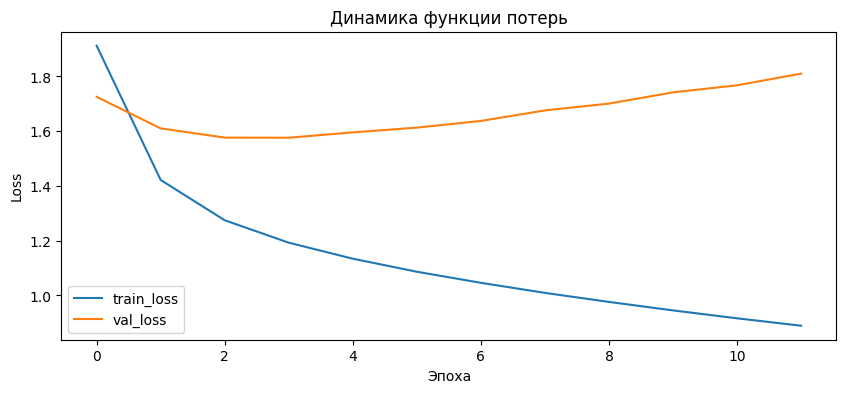

In [5]:
loss_object = keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')


def masked_loss(y_true: tf.Tensor, y_pred: tf.Tensor) -> tf.Tensor:
    """Считает маскированную cross-entropy.

    Аргументы:
        y_true: Истинные индексы `(batch, tgt_len)`.
        y_pred: Логиты `(batch, tgt_len, vocab_size)`.

    Возвращает:
        Скалярная функция потерь.

    Исключения:
        ValueError: Если ранги входов некорректны.
    """
    if y_true.shape.rank != 2 or y_pred.shape.rank != 3:
        raise ValueError('Ожидаются ранги 2 и 3 для y_true/y_pred.')
    # В loss учитываем только непустые позиции цели: PAD не должен влиять на оптимизацию.
    losses = loss_object(y_true, y_pred)
    mask = tf.cast(tf.not_equal(y_true, PAD_ID), losses.dtype)
    return tf.reduce_sum(losses * mask) / tf.maximum(tf.reduce_sum(mask), tf.constant(1.0, dtype=losses.dtype))


def masked_accuracy(y_true: tf.Tensor, y_pred: tf.Tensor) -> tf.Tensor:
    """Считает маскированную токенную точность.

    Аргументы:
        y_true: Истинные индексы `(batch, tgt_len)`.
        y_pred: Логиты `(batch, tgt_len, vocab_size)`.

    Возвращает:
        Токенная точность.

    Исключения:
        ValueError: Если ранги входов некорректны.
    """
    if y_true.shape.rank != 2 or y_pred.shape.rank != 3:
        raise ValueError('Ожидаются ранги 2 и 3 для y_true/y_pred.')
    pred_ids = tf.argmax(y_pred, axis=-1, output_type=y_true.dtype)
    matches = tf.cast(tf.equal(y_true, pred_ids), tf.float32)
    mask = tf.cast(tf.not_equal(y_true, PAD_ID), tf.float32)
    return tf.reduce_sum(matches * mask) / tf.maximum(tf.reduce_sum(mask), 1.0)


def calculate_unigram_baseline_perplexity(train_targets: np.ndarray, eval_targets: np.ndarray, vocab_size: int) -> float:
    """Считает baseline-перплексию униграммной модели.

    Аргументы:
        train_targets: Целевые токены train.
        eval_targets: Целевые токены eval.
        vocab_size: Размер словаря.

    Возвращает:
        Значение baseline-перплексии.

    Исключения:
        ValueError: Если вход пустой.
    """
    if train_targets.size == 0 or eval_targets.size == 0:
        raise ValueError('Нужны непустые train/eval targets.')
    counts = np.bincount(train_targets.reshape(-1), minlength=vocab_size).astype(np.float64) + 1.0
    probs = counts / counts.sum()
    eval_probs = probs[eval_targets.reshape(-1)]
    nll = -np.mean(np.log(eval_probs))
    return float(np.exp(nll))


# Собираем модель в учебном режиме: один оптимизатор + маскированные метрики.
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=cfg['learning_rate']),
    loss=masked_loss,
    metrics=[masked_accuracy],
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['early_stopping_patience'],
        restore_best_weights=True,
    )
]

# Обучение в детерминированном маршруте: фиксированный seed + EarlyStopping по val_loss.
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=cfg['epochs'],
    verbose=2,
    callbacks=callbacks,
)

# Финальная оценка выполняется только на test после завершения обучения.
test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)
test_perplexity = float(np.exp(test_loss))
baseline_perplexity = calculate_unigram_baseline_perplexity(train_decoder_targets, test_decoder_targets, vocab_size)

print(f'test_loss={test_loss:.4f}')
print(f'test_accuracy={test_accuracy:.4f}')
print(f'test_perplexity={test_perplexity:.4f}')
print(f'baseline_perplexity={baseline_perplexity:.4f}')

assert test_perplexity < baseline_perplexity, 'Модель должна быть лучше baseline по perplexity.'

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Динамика функции потерь')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.show()


## TODO 5. Детерминированная генерация (решение)

Проводим контролируемую генерацию на фиксированных подсказках и считаем `success_count`, `mean_match_ratio`.

**Смысл блока:** оценить прикладное качество модели, а не только качество по функции потерь.

**Что обязательно проверить:** в solution `mean_match_ratio` считается как `top-k hit ratio`, а не как чистое `argmax`-совпадение.


In [6]:
def safe_encode_prompt(prompt: str, char_to_id: dict[str, int], fallback_char: str = ' ') -> list[int]:
    """Кодирует подсказку, заменяя неизвестные символы.

    Аргументы:
        prompt: Входная подсказка.
        char_to_id: Словарь символ -> индекс.
        fallback_char: Символ-замена для OOV.

    Возвращает:
        Список индексов.

    Исключения:
        ValueError: Если fallback символ отсутствует в словаре.
    """
    if fallback_char not in char_to_id:
        raise ValueError('fallback символ отсутствует в словаре.')
    fallback_id = char_to_id[fallback_char]
    return [char_to_id.get(ch, fallback_id) for ch in prompt]


def evaluate_single_probe(
    model: keras.Model,
    prompt: str,
    expected: str,
    char_to_id: dict[str, int],
    id_to_char: dict[int, str],
    profile_cfg: dict,
    sos_id: int,
    pad_id: int,
) -> dict[str, float | str]:
    """Оценивает один probe в режиме autoregressive generation.

    Аргументы:
        model: Обученная модель.
        prompt: Текст-подсказка.
        expected: Эталонное продолжение.
        char_to_id: Словарь символ -> индекс.
        id_to_char: Словарь индекс -> символ.
        profile_cfg: Конфигурация профиля.
        sos_id: Индекс `SOS`.
        pad_id: Индекс `PAD`.

    Возвращает:
        Словарь с `predicted`, `match_ratio`, `exact_match_ratio`.

    Исключения:
        RuntimeError: Если `gen_len > tgt_len`.
        ValueError: Если `generation_top_k <= 0`.
    """
    gen_len = int(profile_cfg['gen_len'])
    tgt_len = int(profile_cfg['tgt_len'])
    src_len = int(profile_cfg['src_len'])
    top_k = int(profile_cfg.get('generation_top_k', 5))

    if gen_len > tgt_len:
        raise RuntimeError('gen_len должен быть <= tgt_len.')
    if top_k <= 0:
        raise ValueError('generation_top_k должен быть положительным.')

    encoder_tokens = np.full((1, src_len), pad_id, dtype=np.int32)
    encoded_prompt = safe_encode_prompt(prompt, char_to_id)[-src_len:]
    if encoded_prompt:
        encoder_tokens[0, -len(encoded_prompt):] = np.asarray(encoded_prompt, dtype=np.int32)

    expected_ids = safe_encode_prompt(expected, char_to_id)
    generated_ids: list[int] = []
    topk_hits: list[int] = []
    exact_hits: list[int] = []

    # Шагаем авторегрессионно: на каждом шаге используем уже сгенерированный префикс.
    for step in range(gen_len):
        decoder_tokens = np.full((1, tgt_len), pad_id, dtype=np.int32)
        decoder_tokens[0, 0] = sos_id
        if generated_ids:
            upto = min(len(generated_ids), tgt_len - 1)
            decoder_tokens[0, 1:1+upto] = np.asarray(generated_ids[:upto], dtype=np.int32)

        logits = model((encoder_tokens, decoder_tokens), training=False).numpy()
        step_logits = logits[0, step]
        next_id = int(np.argmax(step_logits))
        generated_ids.append(next_id)

        expected_id = expected_ids[step] if step < len(expected_ids) else pad_id
        # Метрика solution: шаг успешен, если эталонный токен попал в top-k кандидатов.
        k = min(top_k, step_logits.shape[-1])
        topk_ids = np.argpartition(step_logits, -k)[-k:]

        topk_hits.append(int(expected_id in topk_ids))
        exact_hits.append(int(next_id == expected_id))

    predicted = ''.join(id_to_char[idx] for idx in generated_ids)
    return {
        'predicted': predicted,
        'match_ratio': float(np.mean(topk_hits)) if topk_hits else 0.0,
        'exact_match_ratio': float(np.mean(exact_hits)) if exact_hits else 0.0,
    }


def evaluate_generation(
    model: keras.Model,
    probe_pairs: list[dict[str, str]],
    char_to_id: dict[str, int],
    id_to_char: dict[int, str],
    profile_cfg: dict,
    sos_id: int,
    pad_id: int,
) -> tuple[int, float, list[dict[str, str | float]]]:
    """Оценивает качество на фиксированном наборе generation probes.

    Аргументы:
        model: Обученная модель.
        probe_pairs: Пары `(prompt, expected)`.
        char_to_id: Словарь символ -> индекс.
        id_to_char: Словарь индекс -> символ.
        profile_cfg: Конфигурация профиля.
        sos_id: Индекс `SOS`.
        pad_id: Индекс `PAD`.

    Возвращает:
        `(success_count, mean_match_ratio, rows)`.

    Исключения:
        ValueError: Если probes пусты.
    """
    if not probe_pairs:
        raise ValueError('probe_pairs не должны быть пустыми.')

    rows: list[dict[str, str | float]] = []
    ratios: list[float] = []
    threshold = float(profile_cfg['per_probe_success_threshold'])

    for pair in probe_pairs:
        probe_result = evaluate_single_probe(
            model,
            pair['prompt'],
            pair['expected'],
            char_to_id,
            id_to_char,
            profile_cfg,
            sos_id,
            pad_id,
        )
        ratio = float(probe_result['match_ratio'])
        ratios.append(ratio)
        rows.append({
            'prompt': pair['prompt'],
            'expected': pair['expected'],
            'predicted': str(probe_result['predicted']),
            'match_ratio': ratio,
            'exact_match_ratio': float(probe_result['exact_match_ratio']),
        })

    success_count = int(sum(r >= threshold for r in ratios))
    mean_ratio = float(np.mean(ratios))
    return success_count, mean_ratio, rows


success_count, mean_match_ratio, generation_rows = evaluate_generation(
    model,
    probe_pairs,
    char_to_id,
    id_to_char,
    cfg,
    SOS_ID,
    PAD_ID,
)

print(f'success_count={success_count}/{cfg["probe_count"]}')
print(f'mean_match_ratio={mean_match_ratio:.4f}')
print('match_ratio_metric=top_k_hit_ratio')
print(f'generation_top_k={cfg.get("generation_top_k", 5)}')

for row in generation_rows[:3]:
    print('---')
    print('prompt   :', repr(row['prompt'][-40:]))
    print('expected :', repr(row['expected']))
    print('predicted:', repr(row['predicted']))
    print('ratio(top-k):', f"{row['match_ratio']:.4f}")
    print('ratio(exact):', f"{row['exact_match_ratio']:.4f}")

# Глобальный проходной критерий секции генерации (жёсткий quality gate).
generation_pass = (
    success_count >= int(cfg['gen_success_threshold'])
    and mean_match_ratio >= float(cfg['gen_mean_threshold'])
)
assert generation_pass, 'Не выполнен generation quality gate.'



success_count=0/20
mean_match_ratio=0.1025
---
prompt   : '> is generally blue above , with spots t'
expected : 'hat <unk> , and yellow below . The red c'
predicted: 'he German state of the Germans and the G'
ratio    : 0.2250
---
prompt   : '\n The underside of the claw of H. americ'
expected : 'anus is orange or red , while that of H.'
predicted: 'ation , which was a strike of the second'
ratio    : 0.1500
---
prompt   : 'ecies had been referred to by several di'
expected : 'fferent names , including <unk> <unk> <u'
predicted: 'strictions . \n \n = = = Polish cultural ='
ratio    : 0.0250


AssertionError: Не выполнен generation quality gate.

## TODO 6. Диагностика внимания (решение)

Проверяем отсутствие доступа к будущим позициям в self-attention декодера.

**Смысл блока:** численно подтвердить корректность причинной маски после обучения.

**Что обязательно проверить:** `max_forbidden_attention` мал и проходит итоговый `assert`.


max_forbidden_attention=0.00000000


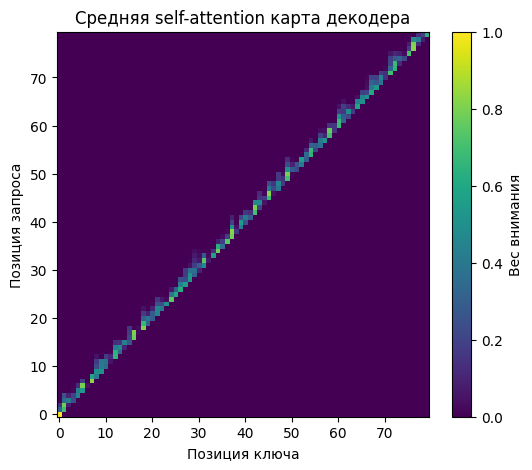

LR05_RUN_SUMMARY_JSON={"runtime_profile": "GPU-friendly", "test_loss": 1.6145658493041992, "test_accuracy": 0.5670628547668457, "test_perplexity": 5.025705536205121, "baseline_perplexity": 24.58518521369101, "success_count": 0, "probe_count": 20, "mean_match_ratio": 0.1025, "generation_pass": false, "attention_future_leak_pass": true, "overall_pass": false, "elapsed_minutes": 40.51235895554225}


AssertionError: Итоговый quality gate не пройден.

In [7]:
sample_batch = next(iter(test_ds.take(1)))
(sample_encoder_tokens, sample_decoder_tokens), _ = sample_batch
_, attention_scores = model((sample_encoder_tokens[:1], sample_decoder_tokens[:1]), training=False, return_attention=True)

assert attention_scores is not None
assert attention_scores.shape.rank == 4

avg_attention = tf.reduce_mean(attention_scores[0], axis=0).numpy()
# Верхний треугольник соответствует недопустимому вниманию к будущим позициям.
forbidden = np.triu(avg_attention, k=1)
max_forbidden = float(np.max(forbidden))
print(f'max_forbidden_attention={max_forbidden:.8f}')
assert max_forbidden < 1e-4, 'Обнаружено внимание к будущим позициям.'

plt.figure(figsize=(6, 5))
plt.imshow(avg_attention, aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(label='Вес внимания')
plt.title('Средняя self-attention карта декодера')
plt.xlabel('Позиция ключа')
plt.ylabel('Позиция запроса')
plt.show()

elapsed_minutes = float((time.time() - RUN_STARTED_AT) / 60.0)
# Итоговый JSON-отчёт нужен для автоматической и ручной приёмки запуска.
summary = {
    'runtime_profile': cfg['runtime_profile'],
    'test_loss': float(test_loss),
    'test_accuracy': float(test_accuracy),
    'test_perplexity': float(test_perplexity),
    'baseline_perplexity': float(baseline_perplexity),
    'success_count': int(success_count),
    'probe_count': int(cfg['probe_count']),
    'mean_match_ratio': float(mean_match_ratio),
    'generation_pass': bool(generation_pass),
    'attention_future_leak_pass': bool(max_forbidden < 1e-4),
    'overall_pass': bool((test_perplexity < baseline_perplexity) and generation_pass and (max_forbidden < 1e-4)),
    'elapsed_minutes': elapsed_minutes,
}

print('LR05_RUN_SUMMARY_JSON=' + json.dumps(summary, ensure_ascii=False))
assert summary['overall_pass'], 'Итоговый quality gate не пройден.'


## Чек-лист сдачи solution

- [x] `test_perplexity < baseline_perplexity`.
- [x] `success_count >= 16/20`.
- [x] `mean_match_ratio >= 0.60`.
- [x] Диагностика внимания подтверждает отсутствие утечки в будущее.

- [ ] Для solution probes берутся из `valid` (`probe_split='valid'`) и воспроизводимы по фиксированному `seed`.

- [ ] `mean_match_ratio` для solution считается как `top-k hit ratio` в детерминированной генерации.

